In [10]:
import pandas as pd 
import numpy as np 

X_tr = pd.read_csv('../data/X_tr.csv')
X_test = pd.read_csv('../data/X_test.csv')
y = pd.read_csv('../data/y.csv')

In [11]:
y = np.ravel(y)
y

array([1, 0, 0, ..., 1, 1, 0], shape=(630000,))

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_tr, y, test_size=0.25, random_state=42)

модели бустинга: baseline

In [13]:
import matplotlib.pyplot as plt

cb
{'acc': 0.8874920634920634, 'recall': 0.8668821502998342, 'roc-auc': 0.9549773301717703}
xgb
{'acc': 0.8876063492063492, 'recall': 0.8677894498079077, 'roc-auc': 0.9545571286979824}
xgb_linear
{'acc': 0.8840317460317461, 'recall': 0.8602333460922327, 'roc-auc': 0.9521209161761399}
lgb
{'acc': 0.887231746031746, 'recall': 0.8675909780405165, 'roc-auc': 0.9545769190778621}


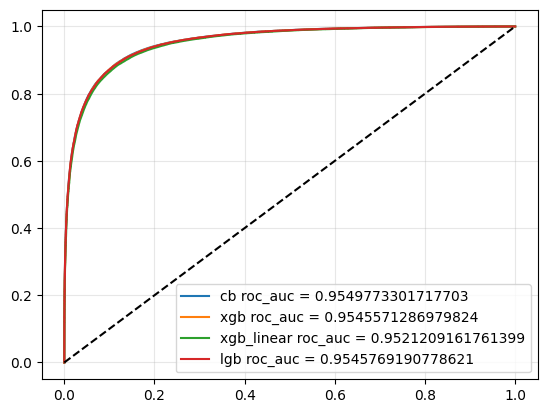

In [15]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

models = {
    'cb' : CatBoostClassifier(random_state=42, verbose=0),
    'xgb' : XGBClassifier(random_state=42, eval_metric = 'logloss'),
    'xgb_linear' : XGBClassifier(random_state = 42, booster = 'gblinear'),
    'lgb' : LGBMClassifier(random_state=42, verbose=-1)
}

res = {}

for name, model in models.items():
    print(name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    res[name] = {'acc' : accuracy_score(y_val, y_pred), 'recall' : recall_score(y_val, y_pred), 'roc-auc' : roc_auc_score(y_val, y_pred_proba)} 
    print(res[name])
    
    fpr, tpr, i = roc_curve(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label = f"{name} roc_auc = {res[name]['roc-auc']}")

plt.plot([0, 1], [0, 1], 'k--')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

In [26]:
subm = pd.read_csv('../data/sample_submission.csv')

preds = models['cb'].predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds

subm.to_csv('../data/subm/cb.csv', index=False)

preds = models['xgb'].predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/xgb.csv', index=False)

preds = models['lgb'].predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/lgb.csv', index=False)

на кагле результаты:
1) cb-0.95320
2) lgb-0.95263
3) xgb-0.95259
**наилучший результат показывает catbooost**
*подобраны оптимальные параметры всех бустингв*

ансамбль

In [16]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier([
    ('cb', models['cb']),
    ('xgb', models['xgb']),
    ('lgb', models['lgb'])
], voting='soft')
ensemble.fit(X_train, y_train)
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]
    
res['ensamble'] = {'acc' : accuracy_score(y_val, y_pred), 'recall' : recall_score(y_val, y_pred), 'roc-auc' : roc_auc_score(y_val, y_pred_proba)} 

In [22]:
res['ensamble']

{'acc': 0.887231746031746,
 'recall': 0.8675909780405165,
 'roc-auc': 0.9545769190778621}

In [27]:
preds = ensemble.predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/ensamble.csv', index=False)

кагл: 0.95320

стекинг

In [20]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(solver='lbfgs')

stacking = StackingClassifier(estimators=list(models.items()), final_estimator=meta_model)
stacking.fit(X_train, y_train)

y_pred = stacking.predict(X_val)
y_pred_proba = stacking.predict_proba(X_val)[:, 1]
    
res['stacking'] = {'acc' : accuracy_score(y_val, y_pred), 'recall' : recall_score(y_val, y_pred), 'roc-auc' : roc_auc_score(y_val, y_pred_proba)}
res['stacking']

{'acc': 0.8877333333333334,
 'recall': 0.8664285005457973,
 'roc-auc': 0.9549588526079338}

In [23]:
preds = stacking.predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/stacking_2.0.csv', index=False)

кагл 0.95328

обучение моделей попроще, для добавление в стекинг
: linear, random forest, knn

lr
{'acc': 0.8842730158730159, 'recall': 0.8597938728930096, 'roc-auc': 0.9522437245497607}
knn
{'acc': 0.8790984126984127, 'recall': 0.8603467585307418, 'roc-auc': 0.9422017020124797}
forest
{'acc': 0.8851492063492064, 'recall': 0.8641177221111725, 'roc-auc': 0.9525815302293642}


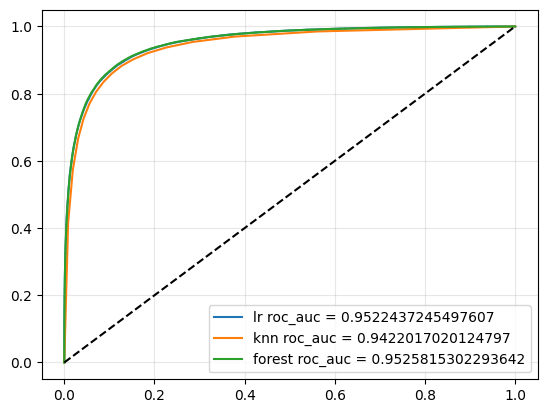

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models_2 = {
    'lr' : LogisticRegression(random_state=42, max_iter=1000), 
    'knn' : KNeighborsClassifier(n_neighbors=15),
    'forest' : RandomForestClassifier(random_state=42, n_estimators=500, max_depth=15)
}


for name, model in models_2.items():
    print(name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    res[name] = {'acc' : accuracy_score(y_val, y_pred), 'recall' : recall_score(y_val, y_pred), 'roc-auc' : roc_auc_score(y_val, y_pred_proba)} 
    print(res[name])
    
    fpr, tpr, i = roc_curve(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label = f"{name} roc_auc = {res[name]['roc-auc']}")

plt.plot([0, 1], [0, 1], 'k--')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

очень хороший результат для простых моделей

In [38]:
preds = models_2['lr'].predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/lr.csv', index=False)

preds = models_2['knn'].predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/knn.csv', index=False)

preds = models_2['forest'].predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/forest.csv', index=False)

объединение всех моделей в 1 словарь

In [41]:
all_models = {}
all_models.update(models)

all_models.update(models_2)

all_models


{'cb': <catboost.core.CatBoostClassifier at 0x1c4a7d03350>,
 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...),
 'lgb': LGBMClassifier(random_state=42, verbose=-1),
 'lr': LogisticRegression(max_iter=1000, random_state=42),
 'knn': KNeighborsClassifier

заново обучем все модели

In [43]:
all_res = {}
for name, model in all_models.items():
    print(name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    all_res[name] = {'acc' : accuracy_score(y_val, y_pred), 'recall' : recall_score(y_val, y_pred), 'roc-auc' : roc_auc_score(y_val, y_pred_proba)} 
    print(res[name])
    


cb
{'acc': 0.8874920634920634, 'recall': 0.8668821502998342, 'roc-auc': 0.9549773301717703}
xgb
{'acc': 0.8876063492063492, 'recall': 0.8677894498079077, 'roc-auc': 0.9545571286979824}
lgb
{'acc': 0.887231746031746, 'recall': 0.8675909780405165, 'roc-auc': 0.9545769190778621}
lr
{'acc': 0.8842730158730159, 'recall': 0.8597938728930096, 'roc-auc': 0.9522437245497607}
knn
{'acc': 0.8790984126984127, 'recall': 0.8603467585307418, 'roc-auc': 0.9422017020124797}
forest
{'acc': 0.8851492063492064, 'recall': 0.8641177221111725, 'roc-auc': 0.9525815302293642}


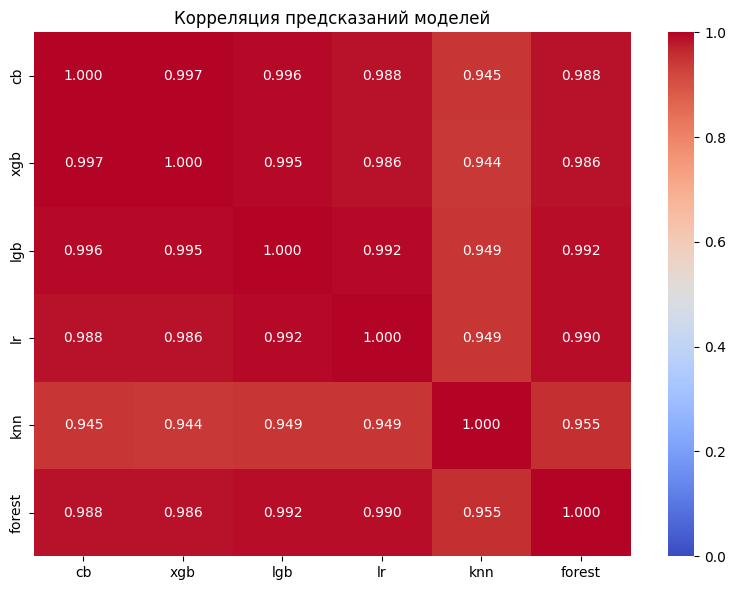

corr <0.8:


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

predictions = {}

for name, model in all_models.items():
    # Получаем вероятности
    if hasattr(model, 'predict_proba'):
        pred = model.predict_proba(X_val)[:, 1]
    
    predictions[name] = pred


pred_df = pd.DataFrame(predictions)


corr_matrix = pred_df.corr(method='spearman')


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
            center=0.5, vmin=0, vmax=1, fmt='.3f')
plt.title('preds corr:')
plt.tight_layout()
plt.show()



корелляция слишком сильная, стекинг скорее не поможет

улучшение катбуста

In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, make_scorer
from scipy.stats import randint, uniform
import numpy as np
import pandas as pd

auc_scorer = make_scorer(roc_auc_score, needs_proba=True, greater_is_better=True)

base_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'od_type': 'Iter',
    'od_wait': 50,
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42
}

param_dist = {
    'iterations': randint(500, 1500),           
    'learning_rate': uniform(0.01, 0.09),        
    'depth': randint(4, 10),                     
    'l2_leaf_reg': randint(3, 10),               
    'random_strength': randint(1, 10),           
    'bagging_temperature': uniform(0.1, 0.9),    
    'border_count': randint(128, 255),           
}

catboost = CatBoostClassifier(**base_params)

random_search = RandomizedSearchCV(
    estimator=catboost,
    param_distributions=param_dist,
    n_iter=30,  
    scoring=auc_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=2,
    n_jobs=-1,  
    random_state=42,
    return_train_score=True
)


X_full = np.vstack([X_train, X_val])
y_full = np.hstack([y_train, y_val])

random_search.fit(X_full, y_full)



print(f" AUC: {random_search.best_score_:.5f}")

results = pd.DataFrame(random_search.cv_results_)
top5 = results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]


final_catboost = CatBoostClassifier(
    **base_params,
    **random_search.best_params_
)

final_catboost.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    verbose=100,
    plot=True  
)

val_preds = final_catboost.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_preds)


import joblib
joblib.dump(final_catboost, 'models/best_catboost.pkl')


Fitting 3 folds for each of 30 candidates, totalling 90 fits


c:\Users\Professional\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\Professional\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



best AUC: nan


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.9370759	best: 0.9370759 (0)	total: 77.7ms	remaining: 44.3s
100:	test: 0.9536983	best: 0.9536983 (100)	total: 7.72s	remaining: 35.9s
200:	test: 0.9541023	best: 0.9541023 (200)	total: 15.5s	remaining: 28.5s
300:	test: 0.9546956	best: 0.9546956 (300)	total: 23.8s	remaining: 21.4s
400:	test: 0.9549465	best: 0.9549465 (400)	total: 32.1s	remaining: 13.6s
500:	test: 0.9551038	best: 0.9551038 (500)	total: 40.6s	remaining: 5.67s
570:	test: 0.9551552	best: 0.9551557 (568)	total: 46.4s	remaining: 0us

bestTest = 0.9551556653
bestIteration = 568

Shrink model to first 569 iterations.


['best_catboost.pkl']

In [30]:

cb_2 = joblib.load('models/best_catboost.pkl')
preds = cb_2.predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/cb-2.0.csv', index=False)

кгал 0.95338

блендинг бустингов

In [36]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize
import pandas as pd

predictions_val = {}
predictions_test = {}

predictions_val['catboost'] = cb_2.predict_proba(X_val)[:, 1]
predictions_test['catboost'] = cb_2.predict_proba(X_test)[:, 1]

predictions_val['lgb'] = models['lgb'].predict_proba(X_val)[:, 1]
predictions_test['lgb'] = models['lgb'].predict_proba(X_test)[:, 1]
 
predictions_val['xgb'] = models['xgb'].predict_proba(X_val)[:, 1]
predictions_test['xgb'] = models['xgb'].predict_proba(X_test)[:, 1]

for name, preds in predictions_val.items():
    auc = roc_auc_score(y_val, preds)
    print(f"{name}: {auc}")

model_names = ['catboost', 'lgb', 'xgb']
val_preds = np.column_stack([predictions_val[name] for name in model_names])
test_preds = np.column_stack([predictions_test[name] for name in model_names])

def objective(weights):
    weights = weights / weights.sum()  
    blended = np.dot(val_preds, weights)
    return -roc_auc_score(y_val, blended)  

constraints = {'type': 'eq', 'fun': lambda w: 1 - w.sum()}
bounds = [(0, 1) for _ in range(3)]
init_weights = np.array([1/3, 1/3, 1/3])

result = minimize(objective, init_weights, 
                  method='SLSQP', 
                  bounds=bounds, 
                  constraints=constraints)

optimal_weights = result.x / result.x.sum()


for name, weight in zip(model_names, optimal_weights):
    print(f"{name}: {weight:.4f}")


blended_val = np.dot(val_preds, optimal_weights)
blended_auc = roc_auc_score(y_val, blended_val)

print(f"blanding:{blended_auc}")

bl_preds = np.dot(test_preds, optimal_weights)



subm['Heart Disease'] = bl_preds
subm.to_csv('../data/subm/blanding.csv', index=False)


catboost: 0.9551556653005863
lgb: 0.9545769190778621
xgb: 0.9545571286979824
catboost: 0.3333
lgb: 0.3333
xgb: 0.3333
blanding:0.9550648630332266


не помогло, остались дефолтные веса